In [1]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

model = joblib.load("final_rf_corefile_model.pkl")
print(" Trained Random Forest model loaded")



 Trained Random Forest model loaded


In [2]:
# DEFINE EXACT TRAINING FEATURES

feature_cols = [
    'model_series',
    'cpu_util_avg',
    'memory_util_avg',
    'port_util_avg',
    'interface_error_rate',
    'connection_rate_cps',
    'syn_flood_events',
    'inspection_drop_rate',
    'fragmented_packet_pct',
    'ssl_decrypt_enabled',
    'image_upgrade_count',
    'reboot_count',
    'failover_events',
    'core_file_count',
    'device_stability_score',
    'severity_encoded',
    'model_sku_A1M',
    'model_sku_A2H',
    'model_sku_A2L',
    'model_sku_A2M'
]


In [3]:
# CREATE NEW FIREWALL DEVICES (PREPROCESSED FORMAT)

rows = 20
new_devices = pd.DataFrame({
    'model_series': np.random.choice([220, 240, 260], rows),
    'cpu_util_avg': np.random.normal(0, 1, rows),
    'memory_util_avg': np.random.normal(0, 1, rows),
    'port_util_avg': np.random.normal(0, 1, rows),
    'interface_error_rate': np.random.normal(0, 1, rows),
    'connection_rate_cps': np.random.normal(0, 1, rows),
    'syn_flood_events': np.random.normal(0, 1, rows),
    'inspection_drop_rate': np.random.normal(0, 1, rows),
    'fragmented_packet_pct': np.random.normal(0, 1, rows),
    'ssl_decrypt_enabled': np.random.choice([0, 1], rows),
    'image_upgrade_count': np.random.randint(0, 3, rows),
    'reboot_count': np.random.randint(0, 3, rows),
    'failover_events': np.random.randint(0, 2, rows),
    'core_file_count': np.random.randint(0, 4, rows),
    'device_stability_score': np.random.normal(0, 1, rows),
    'severity_encoded': np.random.choice([0, 1, 2], rows),
    'model_sku_A1M': np.random.choice([0, 1], rows),
    'model_sku_A2H': np.random.choice([0, 1], rows),
    'model_sku_A2L': np.random.choice([0, 1], rows),
    'model_sku_A2M': np.random.choice([0, 1], rows)
})

# Ensure correct column order
new_devices = new_devices[feature_cols]

In [4]:
#PREDICTION (FIXED)


# Always predict using ONLY training features
X_new = new_devices[feature_cols].copy()

# Predict class
new_devices["core_file_prediction"] = model.predict(X_new)

# Predict probability
new_devices["core_file_probability"] = model.predict_proba(X_new)[:, 1]

# Risk label
new_devices["risk_label"] = new_devices["core_file_prediction"].map({
    0: "✅ Stable",
    1: "⚠️ Core File Risk"
})

print("Prediction successful")
print(new_devices[["core_file_probability", "risk_label"]].head())


Prediction successful
   core_file_probability         risk_label
0                   0.76  ⚠️ Core File Risk
1                   0.84  ⚠️ Core File Risk
2                   0.86  ⚠️ Core File Risk
3                   0.82  ⚠️ Core File Risk
4                   0.74  ⚠️ Core File Risk


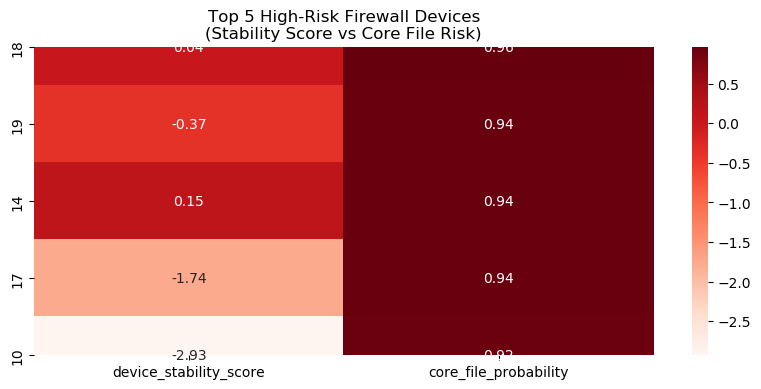

In [5]:
# TOP 5 RISK HEATMAP
top5 = new_devices.sort_values(
    by="core_file_probability", ascending=False
).head(5)

plt.figure(figsize=(10, 4))
sns.heatmap(
    top5[["device_stability_score", "core_file_probability"]],
    annot=True,
    cmap="Reds",
    fmt=".2f"
)
plt.title("Top 5 High-Risk Firewall Devices\n(Stability Score vs Core File Risk)")
plt.show()
